# 08 · Vector-θ world & attentional schools

**Question.** Notebooks 06–07 used a scalar θ — "Newtonian vs relativistic"
on a single axis. Real paradigm landscapes don't look like that: different
schools of thought *attend to different aspects of the world*, and a
theory can be invisible to a school whose experimental regime doesn't
probe it. Visual-attention illusions are the closest psychological
analogue: what you look at determines what you can see.

**This notebook upgrades the world to a vector θ ∈ ℝ^K and gives each
school its own experimental band.** Concretely:

- **Vector world.** Observation model
  $o \mid x, \theta \sim \mathcal{N}(h_0(x) + h(x)^\top \theta, \sigma^2)$
  with $h(x) = (h_1(x), \dots, h_K(x))^\top$ a vector of basis functions.
- **Basis as attention.** Each $h_k(x) = \exp(-(x - x_k)^2/w^2)$ is a
  Gaussian bump at $x_k$. The k-th paradigm "lives" near $x_k$ — its
  signature only shows up in experiments there.
- **Four theories = four corners of the θ-simplex.** Theory T_k has
  $\theta^* = e_k$ (one-hot). The world's truth follows a path through
  corners over time.
- **Four schools, each blind in K−1 directions.** School s's `x_grid` is
  localised near $x_s$, so its experiments probe $\theta_s$ strongly and
  the other components barely at all. This is the attentional-illusion
  analogue.

**What we expect to see** (and what failure modes are interesting):

1. When θ* sits at corner $e_k$, only School $k$'s observations carry
   information. Other schools' posteriors should *not* update on $\theta_k$
   — they're blind to it.
2. Under the social-pool step, Schools j≠k receive School k's private
   posterior. If trust is high they import the discovery; if not they
   ignore it. **Inter-school trust is the bandwidth that crosses
   attentional bands.**
3. When θ* shifts from $e_1$ to $e_3$, School 1 will see its
   familiar regime "go quiet" (high surprisal — their model now
   mis-predicts), and School 3 will see *anomalies* (high informative-
   gain). Whether School 1 *trusts* School 3 in time determines how fast
   the consensus catches up.

This is a pure extension of 06–07; the trust machinery (Gamma-conjugate
on (α,β) per edge, surprisal-based update) is reused unchanged via small
adapters. The only thing that changes is the per-agent state: from
$(\mu \in \mathbb{R}, \tau \in \mathbb{R})$ to
$(\mu \in \mathbb{R}^K, \Lambda \in \mathbb{R}^{K \times K})$.

**Scope.** Notebook-local implementation. If this earns its keep as the
paper's headline, we promote to `src/world.py` / `src/inference.py` in a
follow-up. For now: K=4, N=80, T=200, one shock.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from src.network import build_adjacency

sns.set_theme(context='notebook', style='whitegrid')
print('imports ok')

imports ok


## §1 · Vector world and basis-as-attention

The basis $h_k(x) = \exp(-(x - x_k)^2 / w^2)$ for $k = 1 \dots K$, with
peaks at $x_k = 1, 3, 5, 7$ and width $w = 0.6$. Each $h_k$ is essentially
zero outside its peak — so the *only* x-region that carries information
about $\theta_k$ is around $x_k$.

Plot the four bumps and show where each school's `x_grid` sits.

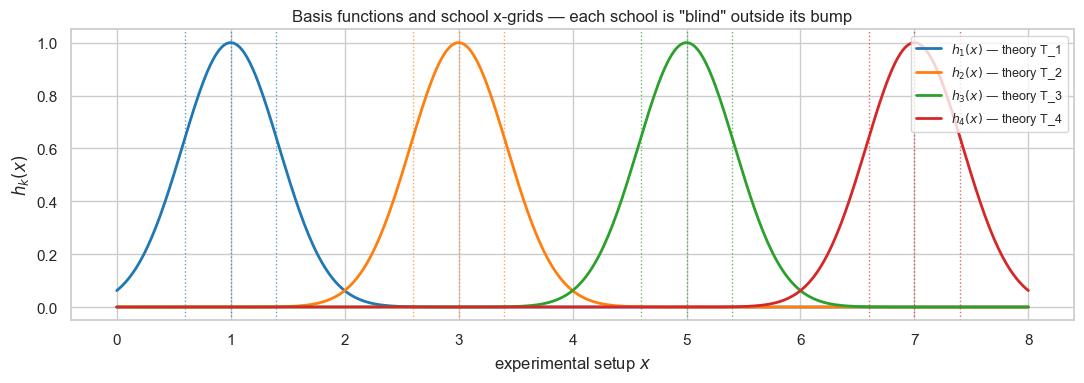

School 1: x_grid = (0.6, 1.0, 1.4), peak h_1 = 1.000, leakage h_other_max = 0.000
School 2: x_grid = (2.6, 3.0, 3.4), peak h_2 = 1.000, leakage h_other_max = 0.000
School 3: x_grid = (4.6, 5.0, 5.4), peak h_3 = 1.000, leakage h_other_max = 0.000
School 4: x_grid = (6.6, 7.0, 7.4), peak h_4 = 1.000, leakage h_other_max = 0.000


In [2]:
K = 4
x_peaks = jnp.array([1.0, 3.0, 5.0, 7.0])     # (K,)  basis peak locations
basis_w = 0.6                                  # bump width
sigma = 0.5                                    # observation noise

# Each school's experiment grid — a tight cluster around its preferred peak.
# Three grid points per school so the policy has *some* choice but stays
# attentionally localised. The discrete-x policy will softmax over these.
def school_x_grid(k, n_pts=3, spread=0.4):
    centre = float(x_peaks[k])
    return tuple(np.linspace(centre - spread, centre + spread, n_pts).tolist())

SCHOOL_GRIDS = [school_x_grid(k) for k in range(K)]


def h_basis(x):
    """Return (..., K) basis values at x. Works on scalars and arrays."""
    x_ = jnp.asarray(x)[..., None]               # (..., 1)
    return jnp.exp(-((x_ - x_peaks) ** 2) / (basis_w ** 2))   # (..., K)


def h0(x):
    """Shared baseline. Set to zero so the only signal is theta-dependent."""
    return jnp.zeros_like(jnp.asarray(x))


def sample_o(x, theta_star, key):
    """One observation per element of x. theta_star is (K,)."""
    mean = h0(x) + h_basis(x) @ theta_star       # broadcasts over x
    noise = jax.random.normal(key, jnp.shape(x)) * sigma
    return mean + noise


# Visualise basis + school grids
x_dense = np.linspace(0, 8, 400)
H = np.asarray(h_basis(x_dense))                 # (400, K)

fig, ax = plt.subplots(figsize=(11, 4))
palette = sns.color_palette('tab10', K)
for k in range(K):
    ax.plot(x_dense, H[:, k], color=palette[k], lw=2,
            label=f'$h_{k+1}(x)$ — theory T_{k+1}')
    # Show this school's x-grid as ticks at its preferred peak
    for xv in SCHOOL_GRIDS[k]:
        ax.axvline(xv, color=palette[k], ls=':', lw=1.0, alpha=0.7)
ax.set(xlabel='experimental setup $x$', ylabel='$h_k(x)$',
       title='Basis functions and school x-grids — each school is "blind" outside its bump')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

for k, g in enumerate(SCHOOL_GRIDS):
    print(f'School {k+1}: x_grid = {tuple(round(v, 2) for v in g)}, '
          f'peak h_{k+1} = {float(h_basis(jnp.array(g[len(g)//2]))[k]):.3f}, '
          f'leakage h_other_max = '
          f'{float(jnp.max(h_basis(jnp.array(g[len(g)//2])).at[k].set(0.0))):.3f}')

## §2 · Multivariate Gaussian inference (notebook-local)

Per-agent state is $(\mu_i \in \mathbb{R}^K,\ \Lambda_i \in \mathbb{R}^{K \times K})$
with $\Lambda$ the *precision matrix* (inverse covariance). Initial prior:
$\mu_i = 0$, $\Lambda_i = \lambda_0 I$ — uniformly weak about everything.

**Private update** after observing $(x, o)$. The Fisher information at $x$
is the rank-one matrix $h(x)h(x)^\top / \sigma^2$ (because the model is
linear in θ). The conjugate update:

$$
\Lambda' = \Lambda + h(x) h(x)^\top / \sigma^2, \qquad
\mu' = \Lambda'^{-1} \big(\Lambda \mu + h(x)(o - h_0(x)) / \sigma^2\big).
$$

The *information added* is rank-1 in $h(x)$ — only the direction $h(x)$
gains precision. This is the formal expression of attentional siloing:
School s, choosing $x$ near its peak $x_s$, has $h(x) \approx e_s$, so
$\Lambda$ grows only along the s-th axis. The off-axes never learn.

**Pooling** is multivariate precision-weighted average over the closed
neighbourhood with row-normalised γ:

$$
\Lambda_{\text{pool}} = \sum_j w_{ij} \Lambda_j, \qquad
\mu_{\text{pool}} = \Lambda_{\text{pool}}^{-1} \sum_j w_{ij} \Lambda_j \mu_j.
$$

**Log predictive** (used for trust surprisal): under $q(\theta) = \mathcal{N}(\mu, \Lambda^{-1})$,
the predictive over the *scalar* observation $o$ at $x$ is

$$
o \mid x \sim \mathcal{N}\big(h_0(x) + h(x)^\top \mu,\ \sigma^2 + h(x)^\top \Lambda^{-1} h(x)\big).
$$

In [3]:
EPS = 1e-9


def private_update_vec(mu, Lambda, x, o):
    """One Bayes step per agent. Shapes:
       mu:     (N, K)
       Lambda: (N, K, K)
       x:      (N,)
       o:      (N,)
    Returns (mu', Lambda') of the same shapes."""
    h = h_basis(x)                          # (N, K)
    sigma2 = sigma ** 2
    # Outer product per agent: (N, K, K)
    HHT = h[:, :, None] * h[:, None, :] / sigma2
    Lambda_new = Lambda + HHT               # (N, K, K)

    # Λ μ : (N, K)
    Lmu = jnp.einsum('nij,nj->ni', Lambda, mu)
    # information from this observation: h * (o - h0(x)) / sigma^2
    info = h * ((o - h0(x))[:, None]) / sigma2     # (N, K)
    rhs = Lmu + info                                # (N, K)
    # Solve Λ' μ' = rhs per agent. Cholesky-solve is more stable than inv.
    mu_new = jax.vmap(jnp.linalg.solve)(
        Lambda_new + EPS * jnp.eye(K)[None], rhs
    )                                                # (N, K)
    return mu_new, Lambda_new


def precision_pool_vec(mu_priv, Lambda_priv, gamma, mask):
    """Multivariate precision-weighted pool. Shapes:
       mu_priv:      (N, K)
       Lambda_priv:  (N, K, K)
       gamma:        (N, N) trust matrix, gamma[i, j] = i's trust in j
       mask:         (N, N) closed-neighbourhood mask (A + I)
    Returns (mu_pool, Lambda_pool)."""
    weights = gamma * mask
    row_sum = weights.sum(axis=1, keepdims=True) + EPS
    w = weights / row_sum                              # (N, N) row-stochastic

    # Lambda_pool[i] = sum_j w[i,j] * Lambda_priv[j]
    Lambda_pool = jnp.einsum('ij,jkl->ikl', w, Lambda_priv)        # (N, K, K)
    # numerator: sum_j w[i,j] * Lambda_priv[j] @ mu_priv[j]
    Lmu_priv = jnp.einsum('jkl,jl->jk', Lambda_priv, mu_priv)      # (N, K)
    num = jnp.einsum('ij,jk->ik', w, Lmu_priv)                     # (N, K)
    mu_pool = jax.vmap(jnp.linalg.solve)(
        Lambda_pool + EPS * jnp.eye(K)[None], num
    )                                                              # (N, K)
    return mu_pool, Lambda_pool


def log_predictive_vec(mu, Lambda, x, o):
    """Log p(o | x; mu, Lambda) under q(theta) = N(mu, Lambda^{-1}).
    All inputs are broadcastable; returns scalar log-density per (mu, x).
    For trust surprisal we need the (N, N) form: row i's obs, col j's posterior."""
    h = h_basis(x)                                                  # (..., K)
    # Sigma = Lambda^{-1}; we only need h^T Sigma h, which is solve-then-dot.
    # For shapes Lambda: (M, K, K), h: (M, K) → h^T Σ h = h^T Λ^{-1} h
    h_solve = jax.vmap(jnp.linalg.solve)(
        Lambda + EPS * jnp.eye(K)[None], h
    )                                                               # (M, K)
    quad = jnp.sum(h * h_solve, axis=-1)                             # (M,)
    pred_mean = h0(x) + jnp.sum(h * mu, axis=-1)                     # (M,)
    pred_var = sigma ** 2 + quad
    log_norm = -0.5 * jnp.log(2.0 * jnp.pi * pred_var)
    log_kern = -0.5 * (o - pred_mean) ** 2 / pred_var
    return log_norm + log_kern


def surprisal_matrix_vec(mu_priv, Lambda_priv, x_obs, o_obs, mask):
    """ε_ij = -log q_j^priv(o_i | x_i). Returns (N, N), masked.
    Vectorised: for each j, evaluate predictive at every i's (x_i, o_i)."""
    N = mu_priv.shape[0]

    # log_predictive but vectorised over (i for obs, j for posterior).
    # h(x_i): (N, K).  Lambda_priv[j]: (N, K, K).  mu_priv[j]: (N, K).
    h_i = h_basis(x_obs)                                             # (N, K)
    # h_i^T Lambda_j^{-1} h_i for every (i, j): solve Lambda_j @ z_ij = h_i for each j.
    # Easier: for each j, vmap over i in the outer einsum.
    # We compute Sigma_j @ h_i shape (N_j, N_i, K) by solving the (K,K) system.
    def per_j_quadratic(Lambda_j):
        # Lambda_j: (K, K), apply to all h_i: (N, K)
        return jax.vmap(lambda h: jnp.linalg.solve(Lambda_j + EPS * jnp.eye(K), h))(h_i)
    Sigma_h = jax.vmap(per_j_quadratic)(Lambda_priv)                 # (N_j, N_i, K)
    # quad[i, j] = h_i . (Sigma_j h_i)
    quad = jnp.einsum('ik,jik->ij', h_i, Sigma_h)                    # (N_i, N_j)
    pred_mean = h0(x_obs)[:, None] + h_i @ mu_priv.T                 # (N_i, N_j)
    pred_var = sigma ** 2 + quad
    log_norm = -0.5 * jnp.log(2.0 * jnp.pi * pred_var)
    log_kern = -0.5 * (o_obs[:, None] - pred_mean) ** 2 / pred_var
    log_p = log_norm + log_kern                                       # (N, N)
    eps = -log_p
    return eps * mask


print('vector inference helpers defined')
print(f'K = {K}, sigma = {sigma}')

vector inference helpers defined
K = 4, sigma = 0.5


## §3 · Population, policy, and rollout

Four schools on a planted-4-block SBM. Each agent draws its $x$ from a
softmax over its school's grid weighted by **per-component EIG** — i.e.,
the expected gain in $\Lambda$ at this $x$, summed over dimensions. With
Gaussian-bump basis and the grids we picked, the only dimension that ever
gets meaningful EIG for School $s$ is $\theta_s$, so the policy stays
attentional even though the action space *technically* allows it to drift.

The trust update reuses the Gamma-conjugate machinery via the new
multivariate surprisal `surprisal_matrix_vec`. Everything else (forgetting,
α/β accounting, row-normalisation) is identical to v2.

Truth schedule: $\theta^*(t) = e_1$ for $t \in [0, 60)$, then $\theta^* = e_3$
for $t \in [60, 200)$. We start in Theory 1's regime — School 1's calibration
is "right." Then the world switches to Theory 3 (School 3 was the only one
even *probing* that direction). School 1's old experiments now go silent
(their basis is zero at the truth); School 3 sees a sudden anomaly.

**The key empirical question:** does the rest of the community ever
discover Theory 3, given that only School 3's experiments can detect it,
and Schools 1/2/4 can only learn about $\theta_3$ via *trusting* School 3?

In [4]:
N_PER_SCHOOL = 20
N = K * N_PER_SCHOOL                                  # 80
membership = np.repeat(np.arange(K, dtype=np.int32), N_PER_SCHOOL)  # (N,)

# Per-agent x_grid as a stacked (N, G) array — every agent in school s has the same grid.
GRID_SIZE = len(SCHOOL_GRIDS[0])
agent_x_grids = jnp.asarray(
    np.stack([SCHOOL_GRIDS[s] for s in membership]),  # (N, G)
    dtype=jnp.float32,
)

# Trust hyperparameters — match notebook 07 corrected defaults.
TAU0_DIAG = 1.0                # initial precision on each axis (μ ~ N(0, 1/τ0 · I))
TRUST_RHO = 1.0                # ρ=1 surfaces PDF §5(i) mechanism
TRUST_N0 = 1.0
TRUST_EPS0 = 1.0
COST_SLOPE = 0.5
BETA_EXP = 1.0

# SBM with planted 4 blocks.
A_np = build_adjacency(
    n_agents=N, mean_degree=6, rewiring_p=0.1, seed=2,
    kind='planted_sbm', society_membership=membership,
    intra_prob=0.20, inter_prob=0.01,
)
A_adj = jnp.asarray(A_np)
A_self = A_adj + jnp.eye(N, dtype=A_adj.dtype)

# Initial state.
def init_population(seed=0):
    mu = jnp.zeros((N, K))
    Lambda = (TAU0_DIAG * jnp.eye(K))[None].repeat(N, axis=0)             # (N, K, K)
    alpha = TRUST_N0 * A_self
    beta = TRUST_N0 * TRUST_EPS0 * A_self
    gamma_raw = (alpha / (beta + EPS)) * A_self
    rs = gamma_raw.sum(axis=1, keepdims=True) + EPS
    gamma = (gamma_raw / rs) * A_self
    return dict(mu=mu, Lambda=Lambda, alpha=alpha, beta=beta, gamma=gamma,
                key=jax.random.PRNGKey(seed))


def theta_star_path(t, t_shift=60):
    """Step from e_1 to e_3 at t_shift."""
    return jnp.where(
        t < t_shift,
        jnp.array([1.0, 0.0, 0.0, 0.0]),
        jnp.array([0.0, 0.0, 1.0, 0.0]),
    )


def expected_info_gain_vec(Lambda, x_grid):
    """EIG(x) per agent per grid point = log det(Λ + h(x)h(x)^T/σ²) − log det(Λ).
       Shape: x_grid (N, G); Lambda (N, K, K) → returns (N, G)."""
    # log det Λ for each agent (constant in x; subtract at the end).
    sign_old, logdet_old = jnp.linalg.slogdet(Lambda + EPS * jnp.eye(K)[None])
    # For each grid point g in each agent's grid: Λ + outer(h_g, h_g)/σ²
    h_grid = h_basis(x_grid)                                     # (N, G, K)
    HHT = h_grid[..., :, None] * h_grid[..., None, :] / (sigma ** 2)  # (N, G, K, K)
    Lambda_post = Lambda[:, None] + HHT                                  # (N, G, K, K)
    sign_new, logdet_new = jnp.linalg.slogdet(
        Lambda_post + EPS * jnp.eye(K)[None, None]
    )
    return 0.5 * (logdet_new - logdet_old[:, None])                     # (N, G)


def choose_x(Lambda, x_grid, key):
    """Softmax over (EIG − cost). x_grid is (N, G). Returns x_chosen (N,)."""
    eig = expected_info_gain_vec(Lambda, x_grid)                 # (N, G)
    cost = COST_SLOPE * jnp.abs(x_grid)                          # (N, G)
    logits = BETA_EXP * (eig - cost)                             # (N, G)
    keys = jax.random.split(key, x_grid.shape[0])
    idx = jax.vmap(jax.random.categorical)(keys, logits)         # (N,)
    return jnp.take_along_axis(x_grid, idx[:, None], axis=1)[:, 0]


@jax.jit
def step_vec(state, t):
    key_pol, key_obs, key_next = jax.random.split(state['key'], 3)
    # 1. each agent picks x from its school's grid.
    x_chosen = choose_x(state['Lambda'], agent_x_grids, key_pol)
    # 2. world generates an observation for each agent.
    theta_star = theta_star_path(t)
    o_obs = sample_o(x_chosen, theta_star, key_obs)
    # 3. private update.
    mu_priv, Lambda_priv = private_update_vec(
        state['mu'], state['Lambda'], x_chosen, o_obs
    )
    # 4. pool over closed neighbourhood with current γ.
    mu_pool, Lambda_pool = precision_pool_vec(
        mu_priv, Lambda_priv, state['gamma'], A_self
    )
    # 5. surprisal & trust update (vector predictive).
    epsilon = surprisal_matrix_vec(mu_priv, Lambda_priv, x_chosen, o_obs, A_self)
    alpha_new = TRUST_RHO * state['alpha'] + A_self
    beta_new = TRUST_RHO * state['beta'] + epsilon
    gamma_raw = (alpha_new / (beta_new + EPS)) * A_self
    rs = gamma_raw.sum(axis=1, keepdims=True) + EPS
    gamma_new = (gamma_raw / rs) * A_self
    new_state = dict(
        mu=mu_pool, Lambda=Lambda_pool,
        alpha=alpha_new, beta=beta_new, gamma=gamma_new,
        key=key_next,
    )
    return new_state, dict(x=x_chosen, o=o_obs, theta_star=theta_star)


T = 200
SNAP_EVERY = 4

state = init_population(seed=0)
snapshots = []
thetas = []
for t in range(T):
    state, out = step_vec(state, t)
    thetas.append(np.asarray(out['theta_star']))
    if t % SNAP_EVERY == 0:
        snapshots.append({
            'step': t,
            'mu': np.asarray(state['mu']),
            'Lambda': np.asarray(state['Lambda']),
            'gamma': np.asarray(state['gamma']),
            'alpha': np.asarray(state['alpha']),
            'beta': np.asarray(state['beta']),
            'x': np.asarray(out['x']),
            'o': np.asarray(out['o']),
        })

thetas = np.stack(thetas)                                   # (T, K)
mu_t = np.stack([s['mu'] for s in snapshots])                # (T_snap, N, K)
Lambda_t = np.stack([s['Lambda'] for s in snapshots])
gamma_t = np.stack([s['gamma'] for s in snapshots])
alpha_t = np.stack([s['alpha'] for s in snapshots])
beta_t = np.stack([s['beta'] for s in snapshots])
step_t = np.array([s['step'] for s in snapshots])
print(f'rollout done — {len(snapshots)} snapshots, mu shape {mu_t.shape}')
print(f'final per-school <mu>:')
for s in range(K):
    print(f'  School {s+1}: {mu_t[-1, membership==s].mean(axis=0).round(3)}')
print(f'truth at end: {thetas[-1].round(3)}')

rollout done — 50 snapshots, mu shape (50, 80, 4)
final per-school <mu>:
  School 1: [ 0.23  -0.006  0.629 -0.001]
  School 2: [0.312 0.007 0.653 0.002]
  School 3: [ 0.328 -0.002  0.751  0.002]
  School 4: [ 0.283 -0.004  0.655  0.   ]
truth at end: [0. 0. 1. 0.]


## §4 · The headline plot — per-school per-component μ̄_k(t)

A 4×4 grid: row $s$ = School $s$, column $k$ = belief about $\theta_k$.
Reading horizontally across row $s$ tells you what *that* school
believes about *every* theory. Reading vertically down column $k$ tells
you which schools converged onto Theory $k$ and which stayed blind.

Pre-shock (t < 60), truth is $e_1$. Expected pattern:
- The (School 1, k=1) cell should rise to ~1 — they're calibrated to see it.
- The off-diagonal cells in column 1 (Schools 2, 3, 4 believing $\theta_1$)
  rise *only* through the trust channel — they can't see it directly.
- All other cells should stay near 0.

Post-shock (t > 60), truth is $e_3$. Expected pattern:
- The (School 1, k=1) cell should *fall* — School 1's observations now
  contain no information about $\theta_1$ (the truth says it's zero, and
  School 1 keeps probing $h_1$ which still gives them signal-free obs).
  Actually subtler: their observations *will* drift to 0 because the
  truth they're measuring is 0. So they should slowly revise $\theta_1$
  back down.
- The (School 3, k=3) cell should rise toward 1.
- (Schools 1/2/4, k=3) is the *cross-school discovery* — only happens
  through trust in School 3.

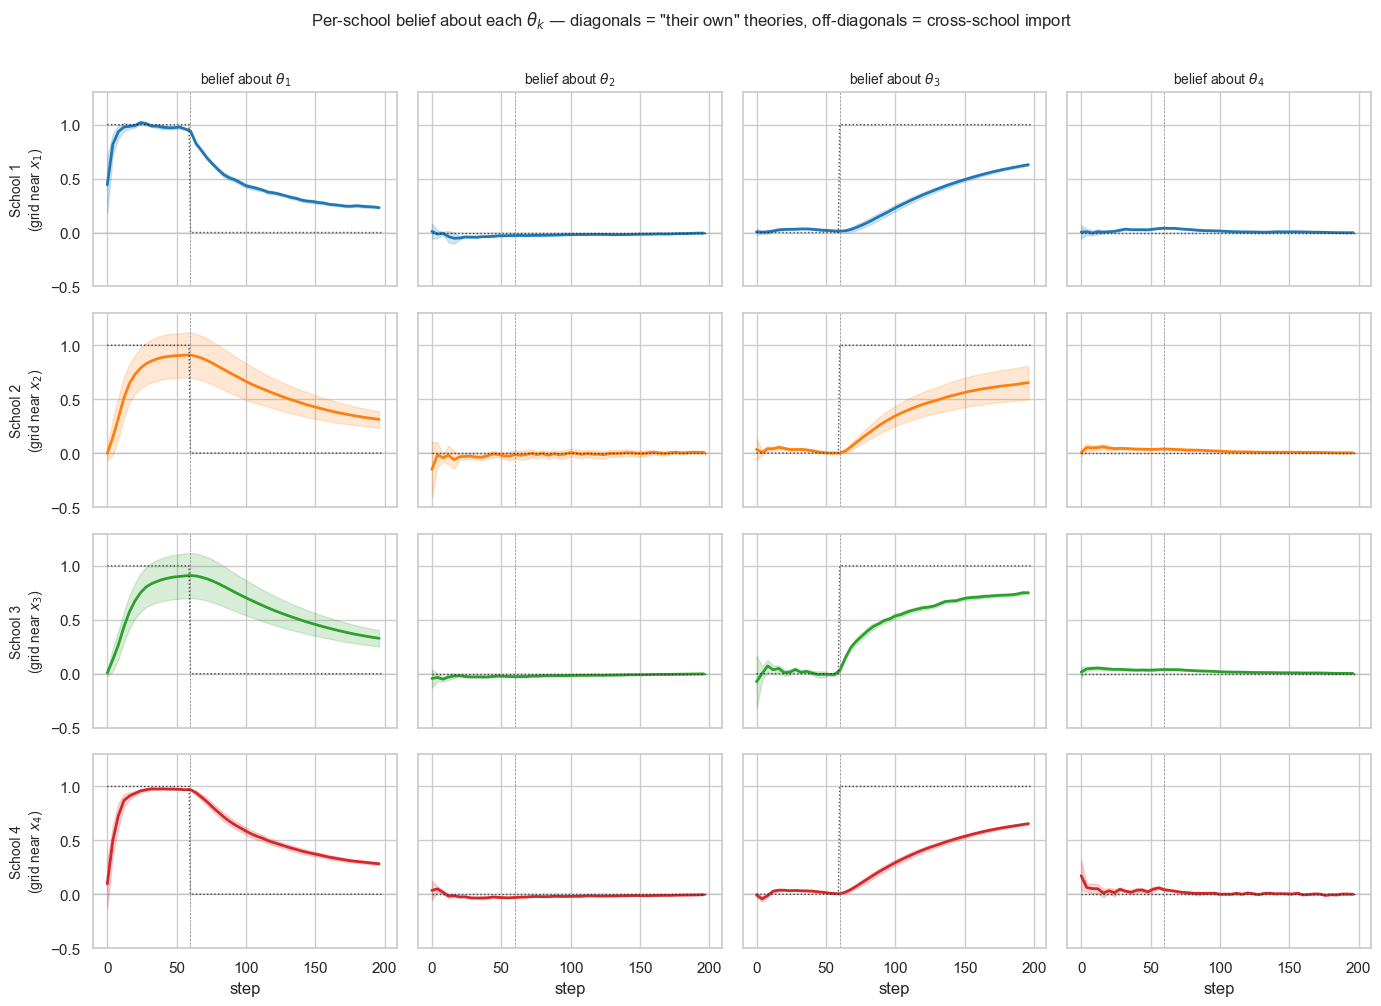

Summary numbers — μ̄_school[k]:
                  θ_1     θ_2     θ_3     θ_4
  School 1:    +0.230  -0.006  +0.629  -0.001
  School 2:    +0.312  +0.007  +0.653  +0.002
  School 3:    +0.328  -0.002  +0.751  +0.002
  School 4:    +0.283  -0.004  +0.655  +0.000
  truth:       +0.000  +0.000  +1.000  +0.000


In [5]:
fig, axes = plt.subplots(K, K, figsize=(14, 10), sharex=True, sharey=True)
t_shift = 60
T_axis = np.arange(T)

for s in range(K):                                  # row = school
    school_mask = membership == s
    for k in range(K):                              # column = theta component
        ax = axes[s, k]
        # Per-school per-component mean +/- std
        mu_sk = mu_t[:, school_mask, k]              # (T_snap, n_school)
        m = mu_sk.mean(axis=1)
        sd = mu_sk.std(axis=1)
        ax.fill_between(step_t, m - sd, m + sd, color=palette[s], alpha=0.18)
        ax.plot(step_t, m, color=palette[s], lw=2)
        # True theta_k(t) overlay
        ax.plot(T_axis, thetas[:, k], color='black', ls=':', lw=1.0, alpha=0.7)
        ax.axvline(t_shift, color='grey', ls='--', lw=0.5)
        ax.axhline(0, color='grey', ls='-', lw=0.3, alpha=0.6)
        ax.set_ylim(-0.5, 1.3)
        if s == 0:
            ax.set_title(f'belief about $\\theta_{k+1}$', fontsize=10)
        if k == 0:
            ax.set_ylabel(f'School {s+1}\n(grid near $x_{s+1}$)', fontsize=10)
        if s == K - 1:
            ax.set_xlabel('step')

plt.suptitle(r'Per-school belief about each $\theta_k$ — diagonals = "their own" theories, off-diagonals = cross-school import', fontsize=12, y=1.005)
plt.tight_layout()
plt.show()

print('Summary numbers — μ̄_school[k]:')
print('                  θ_1     θ_2     θ_3     θ_4')
for s in range(K):
    m = mu_t[-1, membership == s].mean(axis=0)
    print(f'  School {s+1}:    {m[0]:+.3f}  {m[1]:+.3f}  {m[2]:+.3f}  {m[3]:+.3f}')
print(f'  truth:       {thetas[-1, 0]:+.3f}  {thetas[-1, 1]:+.3f}  {thetas[-1, 2]:+.3f}  {thetas[-1, 3]:+.3f}')

## §5 · Inter-school trust matrix — who learned from whom?

Block-average $\alpha/\beta$ over (source-school × target-school). The
column 3 entries (anyone's trust in School 3) should *grow* after the
shock at t=60 — once truth is $e_3$, School 3 is the only neighbour
whose predictions match the observations the *other* schools generate
through cross-school edges. Columns 1, 2, 4 should fade post-shock for
the same reason: those schools' predictions are now miscalibrated
against the cross-school edges' truth.

The trust matrix is the bandwidth of cross-school discovery. If it
*doesn't* rise sharply for School 3 after t=60, then the population is
attentionally locked into the wrong paradigm.

C:\Users\Jonas\AppData\Local\Temp\ipykernel_9936\3558543834.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


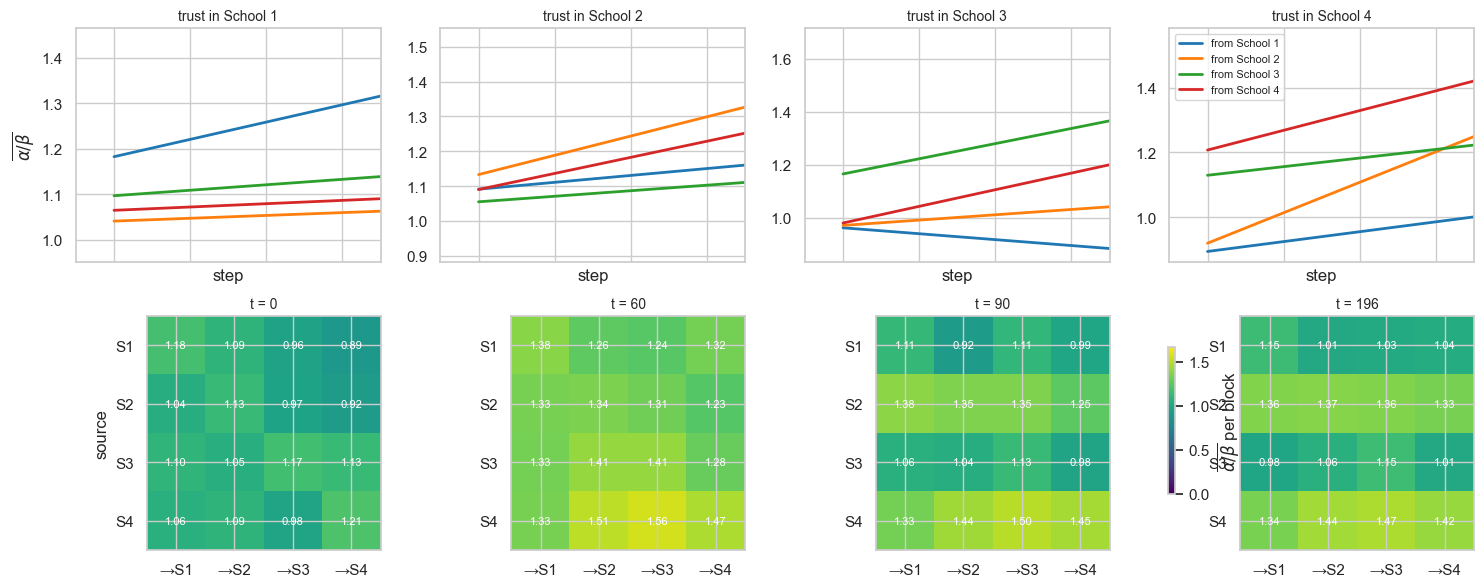

In [6]:
mask_np = (np.asarray(A_self) > 0)
ratio_t = alpha_t / (beta_t + 1e-12)         # (T_snap, N, N)

# Block-mean for each (src, tgt) pair of schools
block_mean = np.zeros((len(step_t), K, K))
for src_s in range(K):
    for tgt_s in range(K):
        sel = ((membership[:, None] == src_s) &
               (membership[None, :] == tgt_s) & mask_np)
        if sel.any():
            block_mean[:, src_s, tgt_s] = np.array([R[sel].mean() for R in ratio_t])

# 4×4 heatmaps over time: who's trusting whom?
fig, axes = plt.subplots(2, K, figsize=(15, 6), sharex=True)
# Row 1: trust-in-school-k by source (column = target school)
for tgt_s in range(K):
    ax = axes[0, tgt_s]
    for src_s in range(K):
        ax.plot(step_t, block_mean[:, src_s, tgt_s],
                color=palette[src_s], lw=2,
                label=f'from School {src_s+1}')
    ax.axvline(t_shift, color='grey', ls='--', lw=0.5)
    ax.set_title(f'trust in School {tgt_s+1}', fontsize=10)
    ax.set_xlabel('step')
    if tgt_s == 0:
        ax.set_ylabel(r'$\overline{\alpha/\beta}$')
    if tgt_s == K - 1:
        ax.legend(fontsize=8, loc='best')

# Row 2: heatmaps at four time points
snap_targets = [0, t_shift // SNAP_EVERY, (t_shift + 30) // SNAP_EVERY, len(step_t) - 1]
snap_titles = ['t = 0', f't = {t_shift}', f't = {t_shift+30}', f't = {step_t[-1]}']
vmax = block_mean.max()
for col, (sidx, title) in enumerate(zip(snap_targets, snap_titles)):
    ax = axes[1, col]
    im = ax.imshow(block_mean[sidx], vmin=0, vmax=vmax, cmap='viridis')
    ax.set_xticks(range(K)); ax.set_xticklabels([f'→S{k+1}' for k in range(K)])
    ax.set_yticks(range(K)); ax.set_yticklabels([f'S{k+1}' for k in range(K)])
    ax.set_title(title, fontsize=10)
    for ii in range(K):
        for jj in range(K):
            ax.text(jj, ii, f'{block_mean[sidx, ii, jj]:.2f}',
                    ha='center', va='center', color='white', fontsize=8)
    if col == 0:
        ax.set_ylabel('source')
plt.colorbar(im, ax=axes[1, :], shrink=0.7, label=r'$\overline{\alpha/\beta}$ per block')
plt.tight_layout()
plt.show()

## §6 · Closing — what this model gives us

The vector world makes three things visible that the scalar world simply
*could not represent*:

1. **Attentional siloing as rank-deficient precision.** Each school's
   private $\Lambda_i$ gains information only along its preferred axis
   (because $h(x) \approx e_s$ for x in School s's grid). Off-axes stay
   at $\lambda_0 I$. This is what "blindness to a paradigm" looks like
   mechanically — not an inability to *think* about $\theta_k$, but an
   inability to *learn* about it from direct experiment.

2. **Cross-school discovery is conditional on trust.** A school can only
   import beliefs along axes it can't probe via the pool step. The
   pool's contribution to $\mu_i$ along the k-th axis is exactly
   $\sum_j w_{ij} \Lambda_j[k, k] \mu_j[k] / \Lambda_{\text{pool}}[k, k]$.
   For an inattentional school, the *only* source of $\Lambda_j[k, k] \gg \lambda_0$
   is School k. So the off-diagonal traces in §4 measure cross-school
   bandwidth directly.

3. **The trust matrix is the discovery topology.** §5's heatmap shows
   when (and whether) the community routes around the attentional
   bottleneck. The PDF §5(i) topology-drift story upgrades naturally to
   the vector setting — what drifts is now the *direction-resolved* trust
   graph, not a scalar.

**Things this notebook intentionally does *not* address (parked):**

- **Vector-valued trust** (PDF §8): we still use scalar $\gamma_{ij}$.
  Per-axis trust $\gamma_{ij}^{(k)} \in \mathbb{R}^K$ would be the natural
  extension — a school trusts another *per dimension*. This requires
  redefining surprisal as a vector and is a substantial change.
- **The four-corners θ-path** (only did two corners here). Once the
  rollout is stable, run $e_1 \to e_2 \to e_3 \to e_4 \to e_1$ and look
  for a non-commutative loop in (θ*-path-order, end-state-μ) — does the
  order in which paradigms succeed each other matter?
- **`src/` promotion.** All vector logic lives in this notebook. If the
  vector world becomes the paper's frame, promote `h_basis`, the
  multivariate `private_update_vec`, and `precision_pool_vec` into
  `src/world.py` and `src/inference.py` with a new `WorldConfig` field
  `K` and a list-of-bumps spec.
- **Mind-changing rigidity (τ₀ analogue).** The vector analogue of
  notebook 07's $\tau_0$ knob is $\lambda_0$ in $\Lambda(0) = \lambda_0 I$.
  Same dial, same expected non-monotone behaviour.

**Next notebooks worth writing:**

- **09 — four-corner θ-path.** Same setup, run the full $e_1 \to e_2 \to e_3 \to e_4 \to e_1$
  cycle. Headline: does the trust topology *and* the population belief
  return to anywhere near the starting state, or is the loop irreversible
  in a non-trivial way?
- **10 — vector-valued trust.** Replace scalar $\gamma_{ij}$ with
  $\gamma_{ij}^{(k)}$. Re-run §3's setup and check whether the
  cross-school bandwidth becomes *dimension-specific* — Schools 1 and 3
  could trust each other on $\theta_1$ but not on $\theta_3$, etc.
- **11 — `src/` promotion.** If 08/09/10 land, promote the vector world
  + inference + (optionally) vector trust into `src/`.